In [611]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio

from tqdm.auto import tqdm
from pathlib import Path

In [612]:
src_dir = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/PhD/Egypt/04_Data/2026_data/"
)
excel_path = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/PhD/Egypt_ERF_data/data_correlation.xlsx"
)


print (excel_path)


C:\Users\hermawan\OneDrive - Stichting Deltares\PhD\Egypt_ERF_data\data_correlation.xlsx


In [613]:
survey_df = pd.read_csv(src_dir.parent / "Result/ind_survey_data_gov_assigned.csv")
distribution_df = pd.read_csv(
    src_dir.parent / "Result/population_density_matrix.csv", index_col="NAME1_"
)
masking_df = pd.read_excel(
    src_dir.parent / "Result/correlation.xlsx", sheet_name="Sheet1"
)
excel_df = pd.read_excel(excel_path, sheet_name="command_unit2")

In [614]:
print(f"Average survey weight: {survey_df['pweight'].mean()}")
print(f"Std of survey weight: {survey_df['pweight'].std()}")

Average survey weight: 341.13162810546737
Std of survey weight: 58.55064178032295


In [615]:
survey_df['sempinc'] = survey_df['sempinc'].fillna(0)
survey_df['irrgwag'] = survey_df['irrgwag'].fillna(0)
survey_df['totwag'] = survey_df['totwag'].fillna(0)

survey_df['totwag'] = survey_df['totwag'] + survey_df['sempinc'] + survey_df['irrgwag'] * 30

In [616]:
female_df = survey_df[survey_df['sex_label'] == 'Female']
#male_df = survey_df[survey_df['sex_label'] == 'Male']

In [617]:
governorates = survey_df[survey_df["NAME1_"].notna()]["NAME1_"].unique()

rng = np.random.default_rng(seed=42)
sample_df = survey_df.copy(deep=True)
sample_df["command_unit"] = None
command_units = distribution_df.columns

gov_indices = {
    gov: idx.to_numpy() for gov, idx in survey_df.groupby("NAME1_").groups.items()
}
female_gov_indices = {
    gov: idx.to_numpy() for gov, idx in female_df.groupby("NAME1_").groups.items()
}
male_gov_indices = {
    gov: idx.to_numpy() for gov, idx in male_df.groupby("NAME1_").groups.items()
}

for gov, idx in gov_indices.items():
    probs = distribution_df.loc[gov].to_numpy()

    assignments = rng.choice(
        command_units,
        size=len(idx),
        p=probs,
    )

    sample_df.loc[idx, "command_unit"] = assignments

sample_df.loc[sample_df["command_unit"] == "other", "command_unit"] = None

sample_df = sample_df[sample_df["command_unit"].notna()]
final_sample = sample_df.merge(
    excel_df, left_on="command_unit", right_on="area", suffixes=("", "_spatial")
)

to_correlate = masking_df.loc[masking_df["correl"] == 1, "variable"]
cols = [c for c in to_correlate if c in final_sample.columns]

In [618]:
female_df = female_df[[col for col in cols + ["NAME1_", "pweight" ] if col in female_df.columns]]

In [619]:
#process categorical data

#marital. 1=married 0=single
female_df["mart_d"] = female_df["mart_d"].between(
    200, 300, inclusive="both"
).astype(int)

#empstab 1=stable 0=not
female_df["empstab"] = np.where(
    female_df["empstab"] == 1,
    1,
    0
)

#migrant 1=yes 0=no
female_df["immigr"] = female_df["immigr"].fillna(3)
female_df["immigr"] = np.where(
    female_df["immigr"] == 3,
    1,
    0
)
#emps 1=paid 0=unpaid
female_df["emps"] = np.where(
    (female_df["emps"] >= 5) & (female_df["emps"] != 6),
    1,
    0
)


In [620]:
v = female_df.columns.difference(["NAME1_", "pweight"])
female_df[v] = female_df[v].apply(pd.to_numeric, errors="coerce")
female_df["pweight"] = pd.to_numeric(female_df["pweight"], errors="coerce")


female_df = female_df.groupby("NAME1_").apply(
    lambda g: g[v].apply(lambda x: np.average(x, weights=g["pweight"])))


In [621]:
base_cols = set(cols + ["area", "arable_km2", "rural_population", "population"])
keywords = ["salinity", "yield", "hectares"]

excel_df = excel_df[
    [
        col for col in excel_df.columns
        if col in base_cols
        or any(word in col.lower() for word in keywords)
    ]
]
#remove production as it seems incorrect
excel_df = excel_df.loc[:, ~excel_df.columns.str.startswith(("salinity"))]
excel_df.head()

,area,population,rural_population,gdp_pc,rwi_median,water_productivity,surface_water_mean,ground_water_mean,supply_demand_ratio,water_supply,...,"hectares_Onions, shallots (green)",hectares_Potatoes,"hectares_Rice, paddy",hectares_Sesame seed,hectares_Sorghum,hectares_Soybeans,hectares_Sugar beet,hectares_Sugar cane,"hectares_Tomatoes, fresh",hectares_Wheat
0,Blk_Air_1,4.886681e+05,17108.839844,10586.715591,0.2365,0.000004,0.000838,0.000074,16.210424,6591.709218,...,546.03845,2.763349e-09,1.877275e-08,0,0.000000e+00,0,6.487863e-09,2.402912e-11,823.014400,9484.449
1,Blk_Air_2,2.763242e+06,45841.378906,11533.990996,0.2070,0.000003,0.000474,0.000071,31.542032,2748.449999,...,1962.42900,1.408621e+03,3.624428e+03,0,0.000000e+00,0,2.433432e+03,1.195065e-07,4319.003516,34129.203
2,Blk_Air_6,4.915848e+05,4863.967773,7606.462231,0.0195,0.000009,0.002594,0.000099,13.095281,5732.737404,...,1126.84070,5.275806e+03,1.252826e+04,0,4.740167e+00,0,8.461197e+03,1.422050e+01,5751.306800,12286.059
3,Blk_Air_7,7.106464e+06,34764.484375,11406.450585,0.3100,0.000015,0.003311,0.000147,120.208076,6948.840745,...,7331.28030,1.755431e+01,3.817297e+01,0,2.226211e-08,0,2.665979e+01,2.133399e-07,5973.081128,112828.410
4,Blk_Air_8,2.160475e+06,11011.501953,10950.987090,0.2250,0.000008,0.003443,0.000125,39.285713,2985.731325,...,1790.46850,1.099196e-11,2.610219e-11,0,9.875973e-15,0,1.762861e-11,2.962792e-14,1707.190800,38040.016


In [622]:
'''already in command_unit2 merged #get production from iDT
PRODUCTION_CSV = REPO_ROOT / "ERF_Data/Data" / "yield.csv"
production_df = pd.read_csv(PRODUCTION_CSV)
production_df = production_df[production_df["year"] == 2020]


crops = [
    "Rice, paddy",
    "Alfalfa for forage",
    "Maize (incl. 0067 and 0068)",
    "Sugar cane",
    "Wheat"
]

production_df = production_df[
    production_df["crop_name_fao"].str.strip().isin(crops)
]

production_df = production_df.drop(
    columns=["a", "b", "year", "comment", "crop_name", "Unnamed: 0"],
    errors="ignore"
)
production_df.head()
'''

'already in command_unit2 merged #get production from iDT\nPRODUCTION_CSV = REPO_ROOT / "ERF_Data/Data" / "yield.csv"\nproduction_df = pd.read_csv(PRODUCTION_CSV)\nproduction_df = production_df[production_df["year"] == 2020]\n\n\ncrops = [\n    "Rice, paddy",\n    "Alfalfa for forage",\n    "Maize (incl. 0067 and 0068)",\n    "Sugar cane",\n    "Wheat"\n]\n\nproduction_df = production_df[\n    production_df["crop_name_fao"].str.strip().isin(crops)\n]\n\nproduction_df = production_df.drop(\n    columns=["a", "b", "year", "comment", "crop_name", "Unnamed: 0"],\n    errors="ignore"\n)\nproduction_df.head()\n'

In [623]:
'''base = production_df.groupby("area_map_name").agg(
    salinity=("salinity", "mean"),
    corrected_yield_pp=("corrected_yield_pp", "sum")
)

crop = production_df.pivot_table(
    index="area_map_name",
    columns="crop_name_fao",
    values=["hectares", "corrected_yield"],
    aggfunc="sum",
    fill_value=0
)

crop.columns = [f"{variable}_{crop_name}" for variable, crop_name in crop.columns]

result_production = base.join(crop)
result_production.head()
'''

'base = production_df.groupby("area_map_name").agg(\n    salinity=("salinity", "mean"),\n    corrected_yield_pp=("corrected_yield_pp", "sum")\n)\n\ncrop = production_df.pivot_table(\n    index="area_map_name",\n    columns="crop_name_fao",\n    values=["hectares", "corrected_yield"],\n    aggfunc="sum",\n    fill_value=0\n)\n\ncrop.columns = [f"{variable}_{crop_name}" for variable, crop_name in crop.columns]\n\nresult_production = base.join(crop)\nresult_production.head()\n'

In [624]:
REPO_ROOT = Path.cwd().parent

CROSSWALK_CSV = REPO_ROOT / "ERF_Data/Data" / "crosswalk" / "command_area_governorate_crosswalk.csv"
crosswalk_df = pd.read_csv(CROSSWALK_CSV)
crosswalk_df.head()


excel_df["_id"] = excel_df["area"].str.extract(r"(\d+)$")[0].astype("Int64")

''''excel_df = excel_df.merge(
    crosswalk_df[
        ["command_area_objectid", "command_area_name"]
    ].drop_duplicates(subset="command_area_objectid"),
    left_on="_id",
    right_on="command_area_objectid",
    how="left"
).drop(columns=["_id", "command_area_objectid"])

excel_df = excel_df.merge(
    result_production,
    left_on="command_area_name",
    right_on="area_map_name",
    how="left"
)
'''
excel_df.head()


,area,population,rural_population,gdp_pc,rwi_median,water_productivity,surface_water_mean,ground_water_mean,supply_demand_ratio,water_supply,...,hectares_Potatoes,"hectares_Rice, paddy",hectares_Sesame seed,hectares_Sorghum,hectares_Soybeans,hectares_Sugar beet,hectares_Sugar cane,"hectares_Tomatoes, fresh",hectares_Wheat,_id
0,Blk_Air_1,4.886681e+05,17108.839844,10586.715591,0.2365,0.000004,0.000838,0.000074,16.210424,6591.709218,...,2.763349e-09,1.877275e-08,0,0.000000e+00,0,6.487863e-09,2.402912e-11,823.014400,9484.449,1
1,Blk_Air_2,2.763242e+06,45841.378906,11533.990996,0.2070,0.000003,0.000474,0.000071,31.542032,2748.449999,...,1.408621e+03,3.624428e+03,0,0.000000e+00,0,2.433432e+03,1.195065e-07,4319.003516,34129.203,2
2,Blk_Air_6,4.915848e+05,4863.967773,7606.462231,0.0195,0.000009,0.002594,0.000099,13.095281,5732.737404,...,5.275806e+03,1.252826e+04,0,4.740167e+00,0,8.461197e+03,1.422050e+01,5751.306800,12286.059,6
3,Blk_Air_7,7.106464e+06,34764.484375,11406.450585,0.3100,0.000015,0.003311,0.000147,120.208076,6948.840745,...,1.755431e+01,3.817297e+01,0,2.226211e-08,0,2.665979e+01,2.133399e-07,5973.081128,112828.410,7
4,Blk_Air_8,2.160475e+06,11011.501953,10950.987090,0.2250,0.000008,0.003443,0.000125,39.285713,2985.731325,...,1.099196e-11,2.610219e-11,0,9.875973e-15,0,1.762861e-11,2.962792e-14,1707.190800,38040.016,8


In [625]:
'''#normalize absolute variable with rural population
col_normalize = [
    col for col in excel_df.columns
    if any(
        word in col.lower()
        for word in [
            "corrected",
            "hectares",
            "arable",
            "water_supply",
            "water_demand",
        ]
    )
    and col.lower() != "arable_km2_scaled"
]

excel_df[col_normalize] = excel_df[col_normalize].div(
    excel_df["rural_population"],
    axis=0
)
excel_df.head()
'''

'#normalize absolute variable with rural population\ncol_normalize = [\n    col for col in excel_df.columns\n    if any(\n        word in col.lower()\n        for word in [\n            "corrected",\n            "hectares",\n            "arable",\n            "water_supply",\n            "water_demand",\n        ]\n    )\n    and col.lower() != "arable_km2_scaled"\n]\n\nexcel_df[col_normalize] = excel_df[col_normalize].div(\n    excel_df["rural_population"],\n    axis=0\n)\nexcel_df.head()\n'

In [626]:

excel_df["_id"] = excel_df["area"].str.extract(r"(\d+)$")[0].astype("Int64")

excel_df = excel_df.merge(
    crosswalk_df[
        ["command_area_objectid", "gov_NAME1_", "pct_of_governorate_area", "pct_of_command_area_area", "command_area_name"]
    ],
    left_on="_id",
    right_on="command_area_objectid",
    how="left"
).drop(columns=["_id", "command_area_objectid"])


In [627]:
group_col = "gov_NAME1_"
source_id = "command_area_name"  # original unit holding the total

total_cols = [
    col for col in excel_df.columns
    if any(
        word in col.lower()
        for word in [
            "corrected",
            "hectares",
            "arable",
            "water_supply",
            "water_demand",
        ]
    )
    and col.lower() != "arable_km2_scaled"
]

# All other numeric variables receive a weighted average
avg_cols = [
    col
    for col in excel_df.select_dtypes(include="number").columns
    if col not in total_cols
    and col not in {
        w,
        "pct_of_command_area_area",
        "pct_of_governorate_area",
        source_id,
    }
]

# Weighted averages
weighted_avg = excel_df.groupby(group_col).apply(
    lambda g: g[avg_cols].apply(
        lambda x: np.average(x, weights=g[w])
    )
)

# Convert weights into shares within each original source area
weight_share = excel_df[w].div(
    excel_df.groupby(source_id)[w].transform("sum")
)

# Distribute each absolute total and then sum by governorate
distributed_totals = excel_df[total_cols].mul(weight_share, axis=0)

absolute_totals = distributed_totals.groupby(
    excel_df[group_col]
).sum(min_count=1)

# Combine both types of results
result_excel = (
    weighted_avg
    .join(absolute_totals, how="outer")
    .reset_index()
)

#result_excel.to_csv("result_excel.csv")

In [ ]:
col_normalize = [
    col for col in excel_df.columns
    if any(
        word in col.lower()
        for word in [
            "corrected",
            "hectares",
            "arable",
            "water_supply",
            "water_demand",
        ]
    )
    and col.lower() != "arable_km2_scaled"
]

result_excel[col_normalize] = result_excel[col_normalize].div(
    result_excel["arable_km2"],
    axis=0
)
result_excel.head()

,gov_NAME1_,population,rural_population,gdp_pc,rwi_median,water_productivity,surface_water_mean,ground_water_mean,supply_demand_ratio,fraction_small,...,"hectares_Onions, shallots (green)",hectares_Potatoes,"hectares_Rice, paddy",hectares_Sesame seed,hectares_Sorghum,hectares_Soybeans,hectares_Sugar beet,hectares_Sugar cane,"hectares_Tomatoes, fresh",hectares_Wheat
0,Alexandria,1.115108e+06,120034.668388,9918.256998,0.008636,0.000006,0.000686,0.000049,79.896070,0.565187,...,0.021825,0.014315,0.275540,0.0,0.000000e+00,0.0,0.146606,0.000377,0.051675,0.539995
1,Assyout,6.115749e+06,37575.467471,11583.885003,0.278890,0.000017,0.002910,0.000120,98.240489,0.982001,...,0.103564,0.017596,0.037895,0.0,3.391575e-03,0.0,0.026809,0.055185,0.107134,1.760919
2,Aswan,1.122928e+06,46420.195248,9249.390463,0.040045,0.000045,0.001241,0.000042,59.595001,0.013906,...,0.018850,0.087636,0.426932,0.0,0.000000e+00,0.0,0.099746,0.000456,0.038409,0.903789
3,Behera,1.541709e+06,77391.899686,11279.321013,0.011473,0.000007,0.000788,0.000062,58.256613,0.624210,...,0.084652,0.058771,0.581984,0.0,1.375383e-10,0.0,0.318537,0.000449,0.170583,1.617558
4,Beni-Suef,6.665638e+06,64649.750259,12350.508693,0.230848,0.000026,0.001275,0.000056,93.002182,0.954791,...,0.084277,0.131931,0.102426,0.0,5.848574e-02,0.0,0.259261,0.138079,0.134452,1.373636


In [629]:
corelate_df = female_df.merge(
     result_excel,
    left_on="NAME1_",
    right_on="gov_NAME1_",
    how="left"
)

corelate_df = corelate_df.drop(
    columns=["pweight", "numwrksc", "disabl"],
    errors="ignore"
)

corelate_df.head()


,age,emps,empstab,female_child_married,female_circumcised,female_contraceptives_decision,female_healthcare_decision,female_labour_participation_rate,female_unemployment_rate,female_violence_emotional,...,"hectares_Onions, shallots (green)",hectares_Potatoes,"hectares_Rice, paddy",hectares_Sesame seed,hectares_Sorghum,hectares_Soybeans,hectares_Sugar beet,hectares_Sugar cane,"hectares_Tomatoes, fresh",hectares_Wheat
0,45.978759,0.0,1.000000,1.8,73.3,97.3,61.1,16.0,8.1,26.4,...,0.103564,0.017596,0.037895,0.0,3.391575e-03,0.0,0.026809,0.055185,0.107134,1.760919
1,40.106128,0.0,0.722984,2.4,36.7,97.2,74.1,40.0,7.0,11.2,...,0.084652,0.058771,0.581984,0.0,1.375383e-10,0.0,0.318537,0.000449,0.170583,1.617558
2,40.347678,0.0,0.893747,3.1,70.3,99.4,89.6,30.0,8.9,12.1,...,0.084277,0.131931,0.102426,0.0,5.848574e-02,0.0,0.259261,0.138079,0.134452,1.373636
3,42.575047,0.0,0.591539,2.1,43.0,96.7,80.0,20.0,8.4,28.4,...,0.217815,0.146251,0.625767,0.0,2.992905e-01,0.0,0.269687,0.160222,0.072241,2.053934
4,46.082384,0.0,0.370971,1.0,10.9,97.4,93.6,24.0,6.1,29.2,...,0.123025,0.026015,0.661001,0.0,1.147171e-01,0.0,0.300280,1.691921,0.033638,1.091430


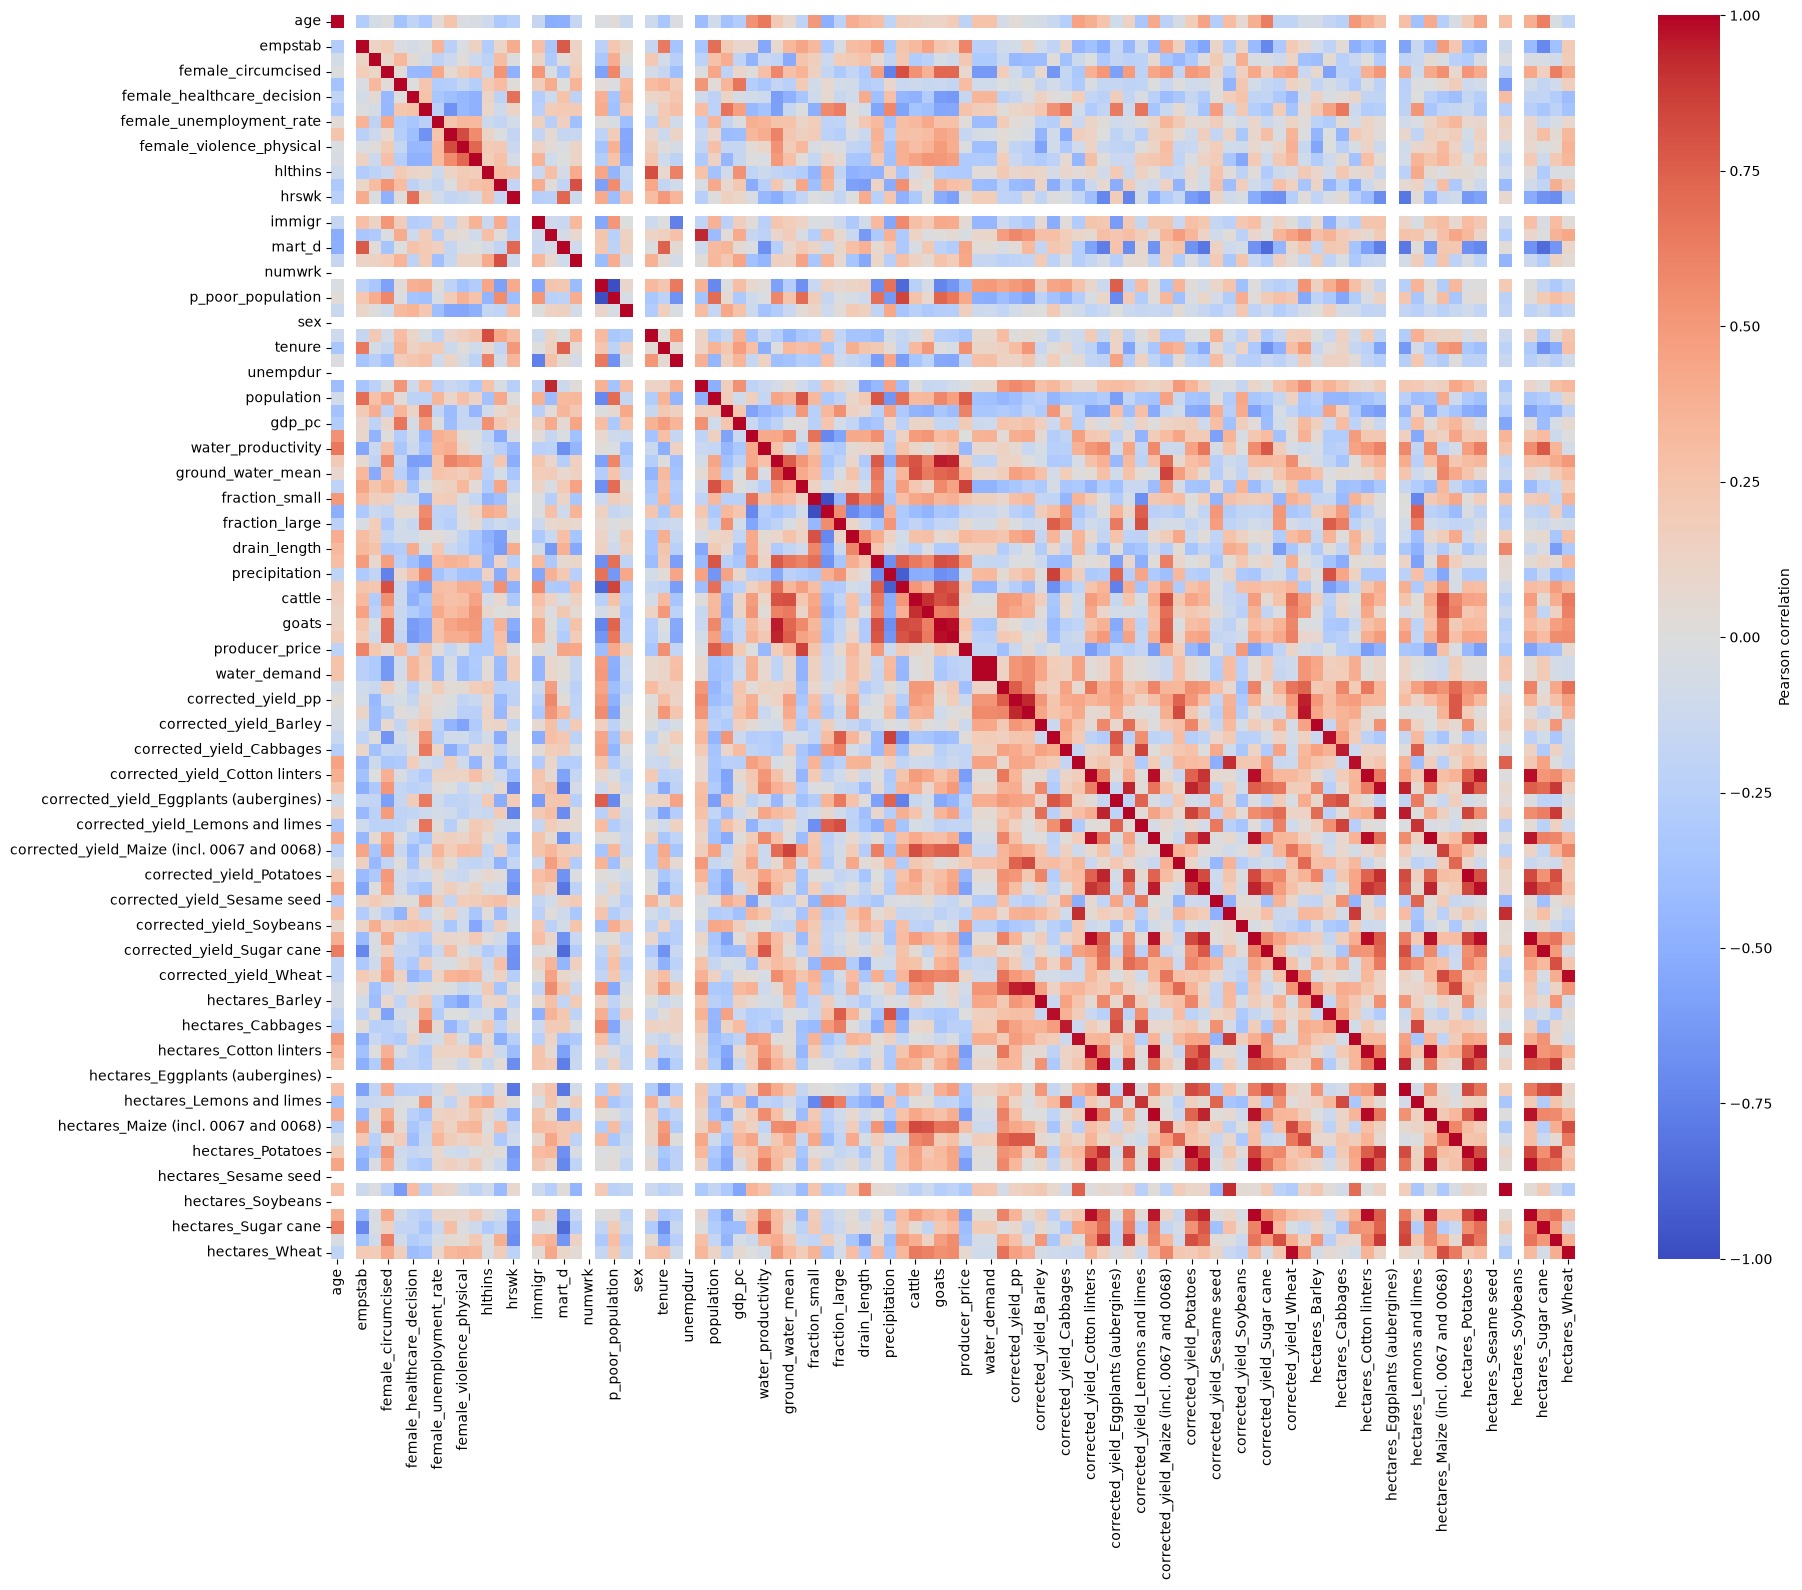

In [630]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pearson correlation for all numeric variables
corr = corelate_df .select_dtypes("number").corr(method="pearson")

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar_kws={"label": "Pearson correlation"}
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


corr.columns = corr.columns.str.replace(",", " ", regex=False)
corr.to_csv("female.csv")